In [1]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

with open('rename_tbl.pkl', 'rb') as f:
    rename_tbl = pickle.load(f)

import matplotlib.pylab as pylab
pylab.rcParams.update({
    'legend.fontsize': 'medium',
    'figure.figsize': (8, 4),
    'axes.labelsize': 'large',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
})

In [2]:
# Load every per-100k time series CSV produced by --dump-stats-ts.
# Filename format: <i>_<trace>_<conf_thres>_stats_ts.csv
ts_dir = '../results/r10i3_stats_ts'
name_re = re.compile(r'^\d+_([a-z]+_[a-z])_([0-9.]+)_stats_ts\.csv$')

frames = []
for path in sorted(glob.glob(f'{ts_dir}/*_stats_ts.csv')):
    m = name_re.match(os.path.basename(path))
    if not m:
        continue
    trace, thres = m.group(1), float(m.group(2))
    df = pd.read_csv(path)
    df['trace'] = trace
    df['trace_lbl'] = rename_tbl.get(trace, trace)
    df['conf_thres'] = thres
    frames.append(df)

ts = pd.concat(frames, ignore_index=True)

# Per-window derived rates. Each row already represents one 100k-request window.
window = 100_000
ts['all_hits'] = ts.hits + ts.revals + ts.stales
ts['all_misses'] = ts.miss_mandatory + ts.miss_expired + ts.miss_evicted
ts['hit_rate'] = ts.all_hits / window
ts['miss_rate'] = ts.all_misses / window
ts['reval_rate'] = ts.revals / window
ts['stale_rate'] = ts.stales / window
ts['req_m'] = ts['all'] / 1e6  # cumulative requests (millions)
# now_ts is trace-relative seconds since the start of the run, not a unix epoch.
ts['time_s'] = ts['now_ts']
ts['time_h'] = ts['now_ts'] / 3600.0
ts['time_d'] = ts['now_ts'] / 86400.0

print(ts.shape, 'rows;', ts.trace.nunique(), 'traces,', ts.conf_thres.nunique(), 'thresholds')
print('time range:', ts.time_d.min(), '→', ts.time_d.max(), 'days')
ts.head()

(92776, 21) rows; 4 traces, 8 thresholds
time range: 1.7976967592592592 → 23.86099537037037 days


,all,now_ts,hits,revals,stales,miss_mandatory,miss_expired,miss_evicted,trace,trace_lbl,...,all_hits,all_misses,hit_rate,miss_rate,reval_rate,stale_rate,req_m,time_s,time_h,time_d
0,100000,155321,90325,0,0,7523,0,2152,cf_b,BOS 2,...,90325,9675,0.90325,0.09675,0.0,0.0,0.1,155321,43.144722,1.797697
1,200000,155519,90154,0,0,7707,0,2139,cf_b,BOS 2,...,90154,9846,0.90154,0.09846,0.0,0.0,0.2,155519,43.199722,1.799988
2,300000,155729,90013,0,0,7649,0,2338,cf_b,BOS 2,...,90013,9987,0.90013,0.09987,0.0,0.0,0.3,155729,43.258056,1.802419
3,400000,155923,90113,0,0,7693,0,2194,cf_b,BOS 2,...,90113,9887,0.90113,0.09887,0.0,0.0,0.4,155923,43.311944,1.804664
4,500000,156112,90389,0,0,7546,0,2065,cf_b,BOS 2,...,90389,9611,0.90389,0.09611,0.0,0.0,0.5,156112,43.364444,1.806852


## Trace overview — requests per hour
Queried straight from the parquet inputs (same paths used by `processing.ipynb`). Each line is one trace's request rate over its own wall-clock duration; x-axis is trace-relative days from the first request.

loaded hourly counts for ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g', 'cf_h', 'fb_a', 'fb_b', 'fb_c', 'wm_t', 'wm_u'] (rolling mean window = 50h)


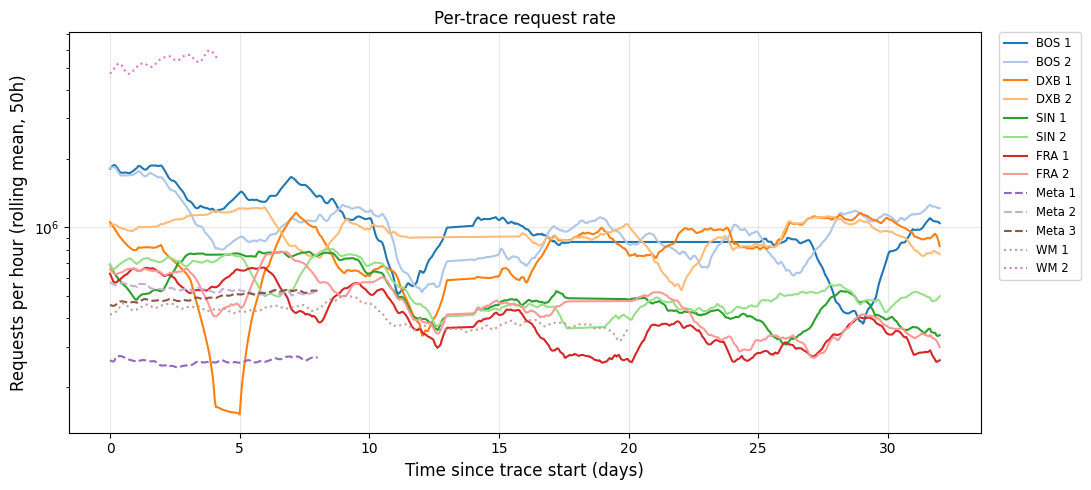

In [3]:
import duckdb, functools
conn = duckdb.connect()
conn.execute("SET memory_limit = '32GB';")

# Memoize query results so re-running the cell doesn't re-scan the parquets.
@functools.lru_cache(maxsize=128)
def hourly(sql: str) -> pd.DataFrame:
    return conn.execute(sql).df()

cf_servers = {
    '106m105': 'cf_a', '106m106': 'cf_b',
    '243m12':  'cf_c', '243m13':  'cf_d',
    '411m264': 'cf_e', '411m325': 'cf_f',
    '472m378': 'cf_g', '472m379': 'cf_h',
}
fb_files = {'reag': 'fb_a', 'rhna': 'fb_b', 'rprn': 'fb_c'}
wm_files = {'t-all': 'wm_t', 'u-all': 'wm_u'}
smooth_hours = 50  # rolling mean window in hours

rph_frames = []
for srv, tr in cf_servers.items():
    try:
        d = hourly(f"""
            select cast(timestamp / 3600 as bigint) as hour, count(*) as n
            from '../traces/cf/parquet/server={srv}/*.parquet'
            group by hour order by hour
        """).copy()
        d['trace'] = tr
        rph_frames.append(d)
    except Exception as e:
        print(f'skipping {tr}: {e}')

fb_ts_divisor = 1000  # fb23 timestamps are milliseconds since epoch
for fname, tr in fb_files.items():
    try:
        d = hourly(f"""
            select cast(timestamp / {fb_ts_divisor} / 3600 as bigint) as hour, count(*) as n
            from '../traces/fb23/{fname}.parquet'
            group by hour order by hour
        """).copy()
        d['trace'] = tr
        rph_frames.append(d)
    except Exception as e:
        print(f'skipping {tr}: {e}')

for fname, tr in wm_files.items():
    try:
        d = hourly(f"""
            select cast(timestamp / 3600 as bigint) as hour, count(*) as n
            from '../traces/wm/{fname}.parquet'
            group by hour order by hour
        """).copy()
        d['trace'] = tr
        rph_frames.append(d)
    except Exception as e:
        print(f'skipping {tr}: {e}')

rph = pd.concat(rph_frames, ignore_index=True)
rph['hour_idx'] = rph['hour'] - rph.groupby('trace')['hour'].transform('min')
rph['time_d'] = rph['hour_idx'] / 24.0
# Smoothed request rate per trace.
rph['n_smooth'] = (rph.sort_values(['trace', 'hour_idx'])
                    .groupby('trace')['n']
                    .transform(lambda s: s.rolling(smooth_hours, min_periods=1, center=True).mean()))
print('loaded hourly counts for', sorted(rph.trace.unique()),
      f'(rolling mean window = {smooth_hours}h)')

def _ls(tr):
    if tr.startswith('cf'): return 'solid'
    if tr.startswith('fb'): return 'dashed'
    if tr.startswith('wm'): return 'dotted'
    return 'solid'

trace_order = sorted(rph.trace.unique())
cmap = plt.get_cmap('tab20')
color = {tr: cmap(i % 20) for i, tr in enumerate(trace_order)}

fig, ax = plt.subplots(figsize=(11, 5))
for tr in trace_order:
    d = rph[rph.trace == tr].sort_values('hour_idx')
    ax.plot(d.time_d, d.n_smooth, label=rename_tbl.get(tr, tr),
            color=color[tr], linestyle=_ls(tr), linewidth=1.5)
ax.set_yscale('log')
ax.set_xlabel('Time since trace start (days)')
ax.set_ylabel(f'Requests per hour (rolling mean, {smooth_hours}h)')
ax.set_title('Per-trace request rate')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='small', ncol=1)
plt.tight_layout()

## Per-window stats over time (one threshold)
Each line is one of the six counters in a single threshold's run, plotted across the trace.

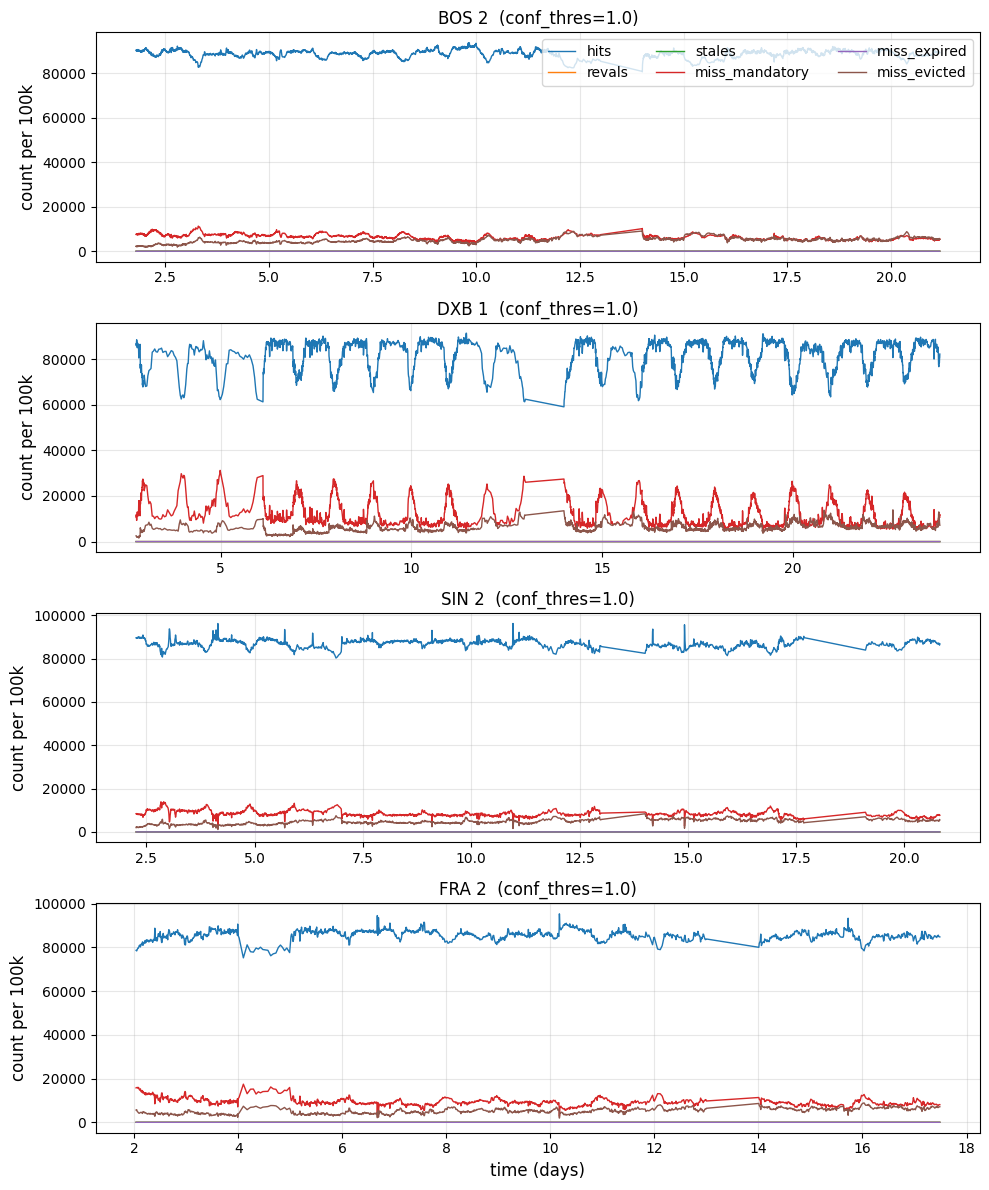

In [4]:
focus_thres = 1.0  # most-aggressive revalidation; tweak as needed
sub = ts[ts.conf_thres == focus_thres]
traces = sorted(sub.trace.unique())

metrics = ['hits', 'revals', 'stales', 'miss_mandatory', 'miss_expired', 'miss_evicted']
fig, axes = plt.subplots(len(traces), 1, figsize=(10, 3 * len(traces)), sharex=False)
if len(traces) == 1:
    axes = [axes]
for ax, trace in zip(axes, traces):
    d = sub[sub.trace == trace].sort_values('now_ts')
    for m in metrics:
        ax.plot(d.time_d, d[m], label=m, linewidth=1)
    ax.set_title(f'{rename_tbl.get(trace, trace)}  (conf_thres={focus_thres})')
    ax.set_ylabel('count per 100k')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (days)')
axes[0].legend(loc='upper right', ncol=3)
plt.tight_layout()

## Hit rate over time across thresholds
One panel per trace; lines colored by revalidation confidence threshold.

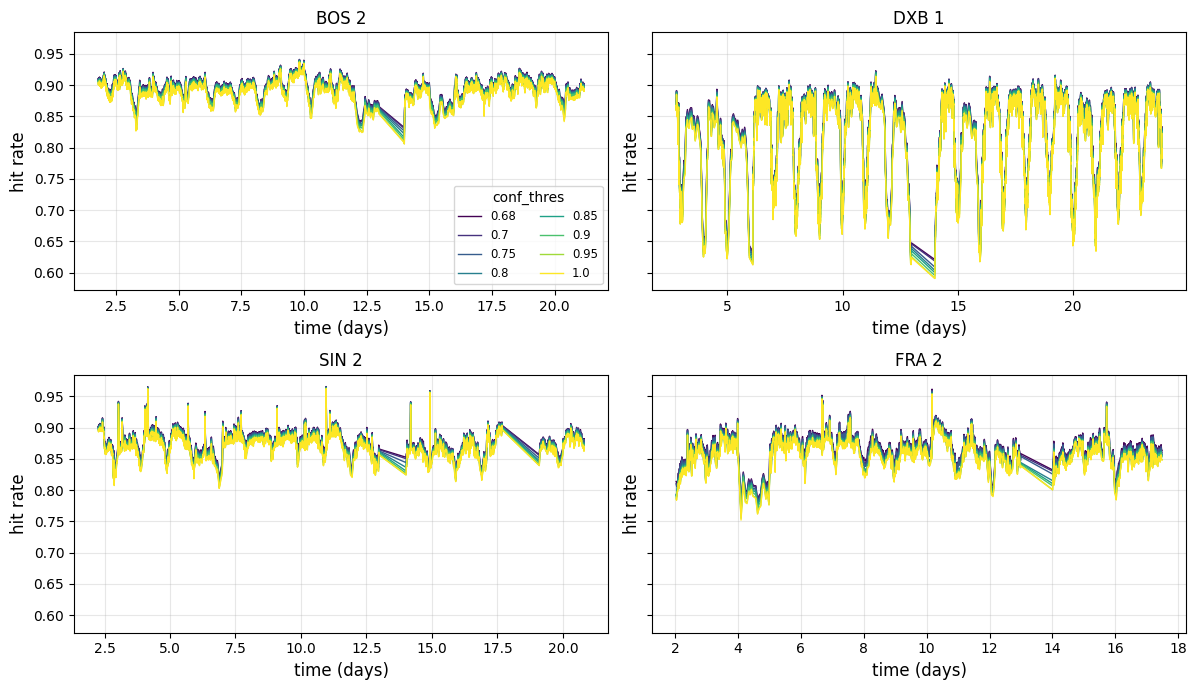

In [5]:
traces = sorted(ts.trace.unique())
thresholds = sorted(ts.conf_thres.unique())
cmap = plt.get_cmap('viridis')
thres_color = {t: cmap(i / max(1, len(thresholds) - 1)) for i, t in enumerate(thresholds)}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=True)
for ax, trace in zip(axes.flat, traces):
    for t in thresholds:
        d = ts[(ts.trace == trace) & (ts.conf_thres == t)].sort_values('now_ts')
        ax.plot(d.time_d, d.hit_rate, label=f'{t}', color=thres_color[t], linewidth=1)
    ax.set_title(rename_tbl.get(trace, trace))
    ax.set_ylabel('hit rate')
    ax.set_xlabel('time (days)')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(title='conf_thres', loc='lower right', ncol=2, fontsize='small')
plt.tight_layout()

## Stacked miss-type breakdown over time
Mandatory / expired / evicted per 100k window for a single (trace, threshold).

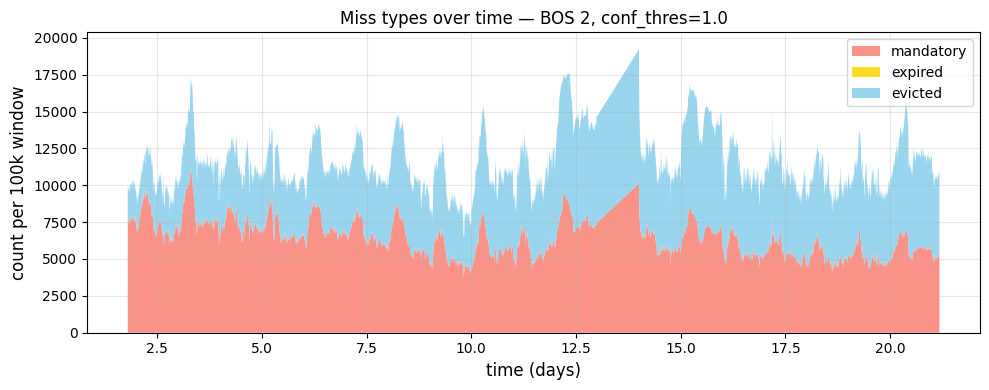

In [6]:
focus_trace = traces[0]
focus_thres = 1.0
d = ts[(ts.trace == focus_trace) & (ts.conf_thres == focus_thres)].sort_values('now_ts')

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(
    d.time_d,
    d.miss_mandatory, d.miss_expired, d.miss_evicted,
    labels=['mandatory', 'expired', 'evicted'],
    colors=['salmon', 'gold', 'skyblue'], alpha=0.85,
)
ax.set_title(f'Miss types over time — {rename_tbl.get(focus_trace, focus_trace)}, conf_thres={focus_thres}')
ax.set_xlabel('time (days)')
ax.set_ylabel('count per 100k window')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Revalidation activity over time across thresholds
Lower threshold → more revalidations fired; this view shows how that ramps in/out as the trace evolves.

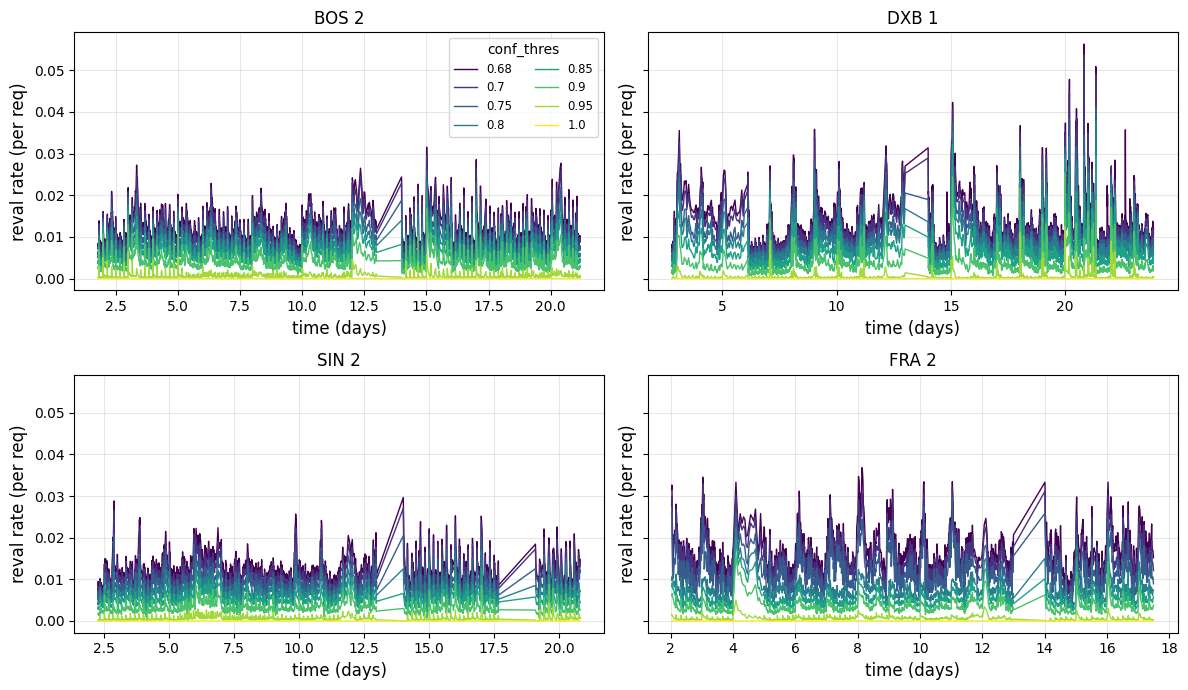

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=True)
for ax, trace in zip(axes.flat, traces):
    for t in thresholds:
        d = ts[(ts.trace == trace) & (ts.conf_thres == t)].sort_values('now_ts')
        ax.plot(d.time_d, d.reval_rate, label=f'{t}', color=thres_color[t], linewidth=1)
    ax.set_title(rename_tbl.get(trace, trace))
    ax.set_xlabel('time (days)')
    ax.set_ylabel('reval rate (per req)')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(title='conf_thres', loc='upper right', ncol=2, fontsize='small')
plt.tight_layout()

## Hit rate improvement vs. baseline (conf_thres = 1.0)
For each (trace, window), subtract the hit rate at `conf_thres=1.0` from the hit rate at every other threshold. Positive = the lower threshold revalidated more aggressively and recovered hits the baseline lost (mostly via fewer expired misses).

,trace,conf_thres,mean_delta_pp,median_delta_pp
0,cf_b,0.68,0.899319,0.8560
1,cf_b,0.70,0.821427,0.7820
2,cf_b,0.75,0.677111,0.6420
3,cf_b,0.80,0.575127,0.5420
4,cf_b,0.85,0.462793,0.4340
5,cf_b,0.90,0.306473,0.2880
6,cf_b,0.95,0.048775,0.0440
7,cf_c,0.68,1.046528,0.9610
8,cf_c,0.70,0.962246,0.8820
9,cf_c,0.75,0.802945,0.7315


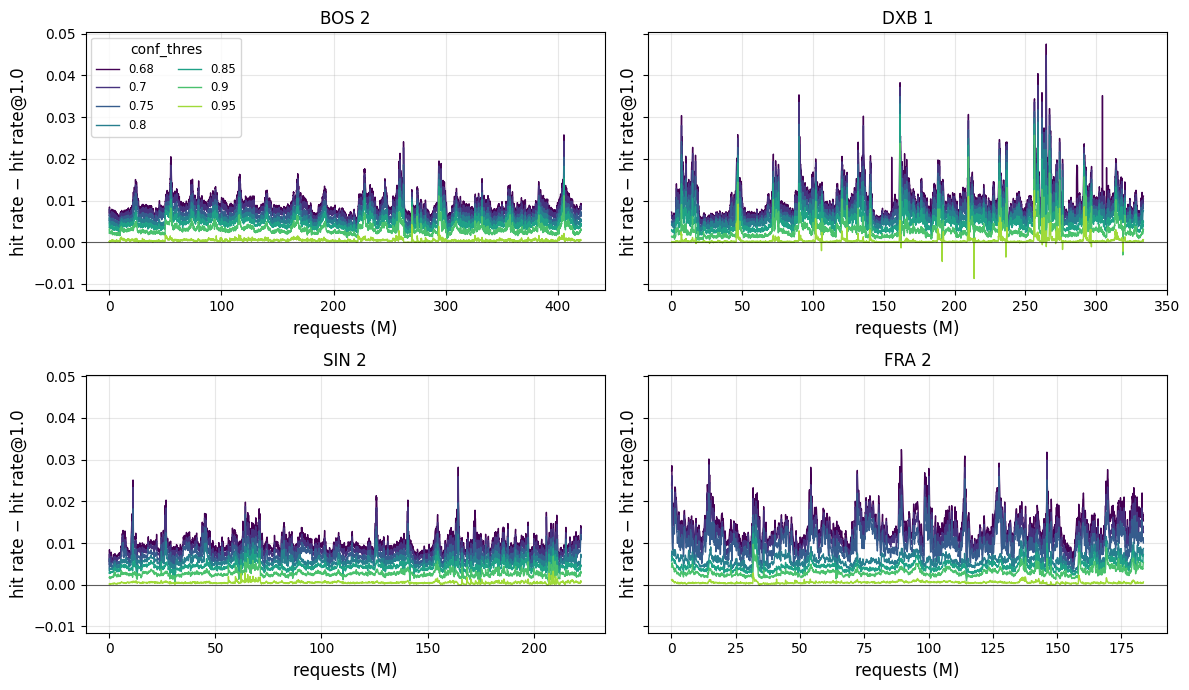

In [8]:
baseline_thres = 1.0
baseline = (ts[ts.conf_thres == baseline_thres]
            [['trace', 'all', 'hit_rate']]
            .rename(columns={'hit_rate': 'hit_rate_baseline'}))

imp = ts.merge(baseline, on=['trace', 'all'], how='inner')
imp['hit_rate_delta'] = imp.hit_rate - imp.hit_rate_baseline

# Drop the baseline-vs-baseline line (always zero) to declutter.
imp_plot = imp[imp.conf_thres != baseline_thres]
plot_thresholds = sorted(imp_plot.conf_thres.unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=True)
for ax, trace in zip(axes.flat, traces):
    for t in plot_thresholds:
        d = imp_plot[(imp_plot.trace == trace) & (imp_plot.conf_thres == t)].sort_values('all')
        ax.plot(d.req_m, d.hit_rate_delta, label=f'{t}', color=thres_color[t], linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.set_title(rename_tbl.get(trace, trace))
    ax.set_xlabel('requests (M)')
    ax.set_ylabel(f'hit rate − hit rate@{baseline_thres}')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(title='conf_thres', loc='best', ncol=2, fontsize='small')
plt.tight_layout()

# Mean improvement summary per (trace, threshold), in percentage points.
summary = (imp_plot.groupby(['trace', 'conf_thres'])
           .agg(mean_delta_pp=('hit_rate_delta', lambda s: 100 * s.mean()),
                median_delta_pp=('hit_rate_delta', lambda s: 100 * s.median()))
           .reset_index()
           .sort_values(['trace', 'conf_thres']))
summary

## Non-mandatory miss rate reduction vs. baseline (conf_thres = 1.0)
Non-mandatory misses = `miss_expired + miss_evicted` — the misses that revalidation can actually attack (compulsory misses are unavoidable). For each (trace, window), compute `(baseline - current) / baseline * 100`. Positive = the lower threshold avoided some non-mandatory misses the baseline incurred.

,trace,conf_thres,mean_red_pct,median_red_pct
0,cf_b,0.68,20.649856,19.146432
1,cf_b,0.70,18.863481,17.505818
2,cf_b,0.75,15.566235,14.441566
3,cf_b,0.80,13.192824,12.351671
4,cf_b,0.85,10.614442,9.925257
5,cf_b,0.90,7.005664,6.611711
6,cf_b,0.95,1.109924,1.009305
7,cf_c,0.68,17.476523,17.080808
8,cf_c,0.70,16.106561,15.722092
9,cf_c,0.75,13.422320,13.091092


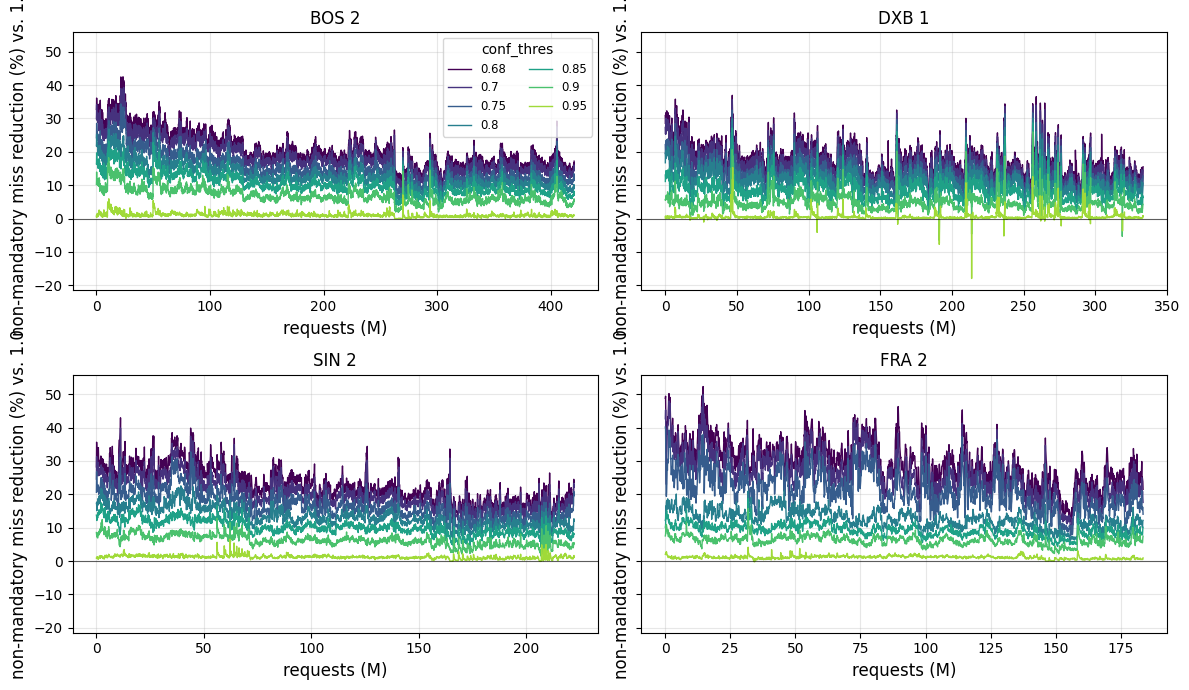

In [9]:
baseline_thres = 1.0
ts['nonmand_miss'] = ts.miss_expired + ts.miss_evicted

baseline_nm = (ts[ts.conf_thres == baseline_thres]
               [['trace', 'all', 'nonmand_miss']]
               .rename(columns={'nonmand_miss': 'nonmand_miss_baseline'}))

red = ts.merge(baseline_nm, on=['trace', 'all'], how='inner')
# Guard against division-by-zero windows (baseline had no non-mandatory misses).
red['nonmand_miss_red_pct'] = np.where(
    red.nonmand_miss_baseline > 0,
    (red.nonmand_miss_baseline - red.nonmand_miss) / red.nonmand_miss_baseline * 100.0,
    np.nan,
)

red_plot = red[red.conf_thres != baseline_thres]
plot_thresholds = sorted(red_plot.conf_thres.unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=True)
for ax, trace in zip(axes.flat, traces):
    for t in plot_thresholds:
        d = red_plot[(red_plot.trace == trace) & (red_plot.conf_thres == t)].sort_values('all')
        ax.plot(d.req_m, d.nonmand_miss_red_pct, label=f'{t}', color=thres_color[t], linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.set_title(rename_tbl.get(trace, trace))
    ax.set_xlabel('requests (M)')
    ax.set_ylabel(f'non-mandatory miss reduction (%) vs. {baseline_thres}')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(title='conf_thres', loc='best', ncol=2, fontsize='small')
plt.tight_layout()

summary_nm = (red_plot.groupby(['trace', 'conf_thres'])
              .agg(mean_red_pct=('nonmand_miss_red_pct', 'mean'),
                   median_red_pct=('nonmand_miss_red_pct', 'median'))
              .reset_index()
              .sort_values(['trace', 'conf_thres']))
summary_nm

## BOS 1 (cf_a) zoom — steady state after 100M requests
Drop the warm-up window so the per-window curves reflect steady-state behavior.

,mean,median,std
conf_thres,,,
0.68,16.25,15.97,3.84
0.70,14.98,14.72,3.72
0.75,12.60,12.29,3.36
0.80,10.85,10.61,3.16
0.85,8.21,7.90,2.92
0.90,4.68,4.27,2.34
0.95,0.61,0.34,1.15


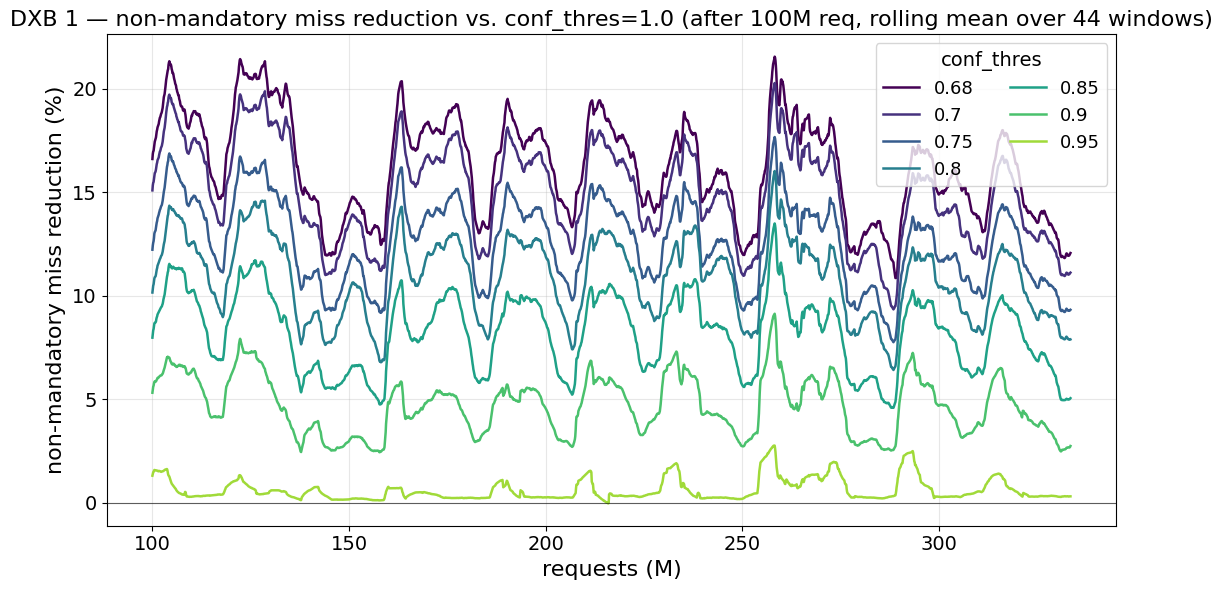

In [10]:
focus_trace = 'cf_c'
start_req = 100_000_000
smooth_win = 44  # rolling window in 100k-request units (≈2.5M req)

d = red_plot[(red_plot.trace == focus_trace) & (red_plot['all'] >= start_req)]
plot_thresholds = sorted(d.conf_thres.unique())

fig, ax = plt.subplots(figsize=(11, 6))
for t in plot_thresholds:
    dd = d[d.conf_thres == t].sort_values('all').copy()
    dd['smoothed'] = dd.nonmand_miss_red_pct.rolling(smooth_win, min_periods=1, center=True).mean()
    ax.plot(dd.req_m, dd.smoothed, label=f'{t}', color=thres_color[t], linewidth=1.8)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
ax.set_title(
    f'{rename_tbl.get(focus_trace, focus_trace)} — non-mandatory miss reduction vs. conf_thres=1.0 '
    f'(after {start_req // 1_000_000}M req, rolling mean over {smooth_win} windows)',
    fontsize=16,
)
ax.set_xlabel('requests (M)', fontsize=16)
ax.set_ylabel('non-mandatory miss reduction (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(title='conf_thres', loc='best', ncol=2, fontsize=13, title_fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()

(d.groupby('conf_thres')
   .nonmand_miss_red_pct.agg(['mean', 'median', 'std'])
   .round(2))

## conf_thres = 0.75 across all four traces
Each line is one trace's smoothed non-mandatory miss reduction vs. its own `conf_thres=1.0` baseline.

,mean,median,std
trace,,,
BOS 2,13.17,12.35,3.60
DXB 1,11.47,11.26,3.32
SIN 2,13.43,12.96,2.99
FRA 2,12.67,12.63,2.66


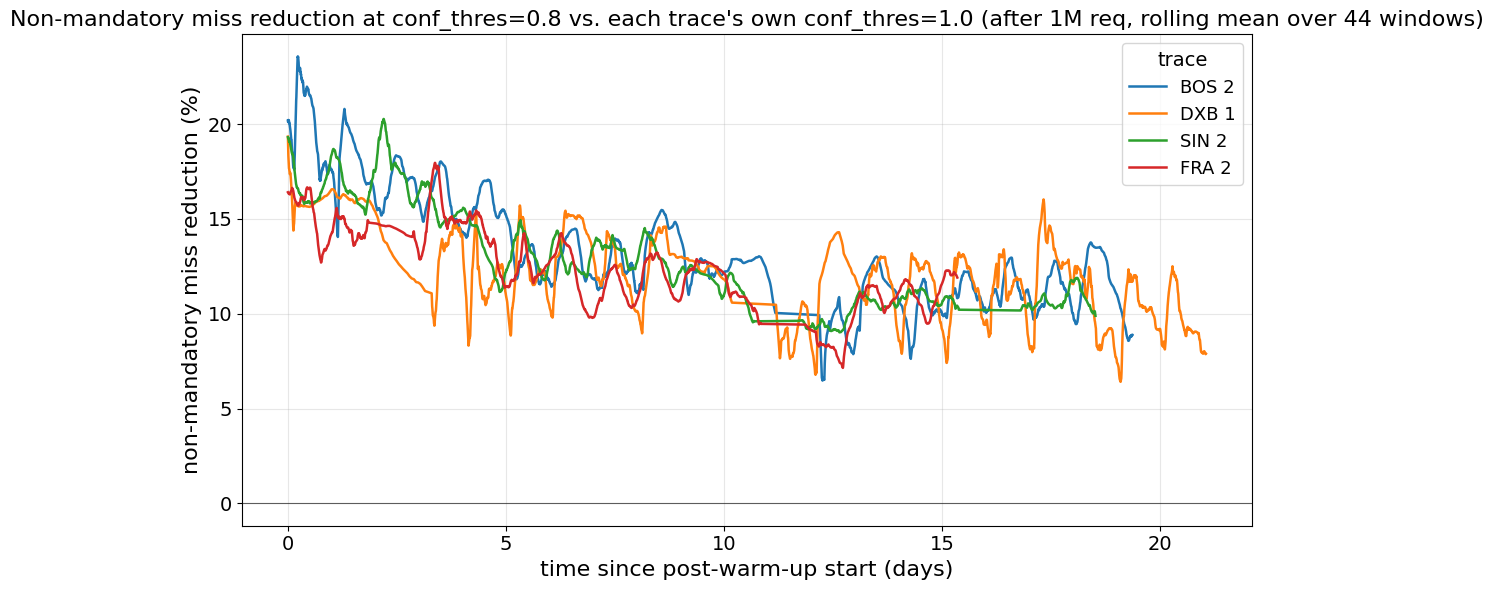

In [11]:
focus_thres = 0.8
start_req = 1_000_000
num_reqs = 500_000_000
smooth_win = 44

d = red_plot[(red_plot.conf_thres == focus_thres) & (red_plot['all'] >= start_req)].copy()
d['time_d'] = d['now_ts'] / 86400.0  # trace-relative seconds → days
# Normalise each trace's clock so all curves start at day 0 of the post-warm-up window.
d['time_d_norm'] = d['time_d'] - d.groupby('trace')['time_d'].transform('min')

plot_traces = sorted(d.trace.unique())
trace_cmap = plt.get_cmap('tab10')
trace_color = {tr: trace_cmap(i) for i, tr in enumerate(plot_traces)}

fig, ax = plt.subplots(figsize=(11, 6))
for tr in plot_traces:
    dd = d[d.trace == tr].sort_values('now_ts').copy()
    dd['smoothed'] = dd.nonmand_miss_red_pct.rolling(smooth_win, min_periods=1, center=True).mean()
    ax.plot(dd.time_d_norm, dd.smoothed, label=rename_tbl.get(tr, tr), color=trace_color[tr], linewidth=1.8)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
ax.set_title(
    f'Non-mandatory miss reduction at conf_thres={focus_thres} vs. each trace\'s own conf_thres=1.0 '
    f'(after {start_req // 1_000_000}M req, rolling mean over {smooth_win} windows)',
    fontsize=16,
)
ax.set_xlabel('time since post-warm-up start (days)', fontsize=16)
ax.set_ylabel('non-mandatory miss reduction (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(title='trace', loc='best', fontsize=13, title_fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()

(d.groupby('trace')
   .nonmand_miss_red_pct.agg(['mean', 'median', 'std'])
   .round(2)
   .rename(index=rename_tbl))

## Remaining non-mandatory miss ratio over time (BOS 1)
Y = `1 − non-mandatory miss reduction` = `current_nonmand_miss / baseline_nonmand_miss`. Lower is better (smaller fraction of the baseline's avoidable misses still happen). Formatted with larger fonts to match the paper figures.

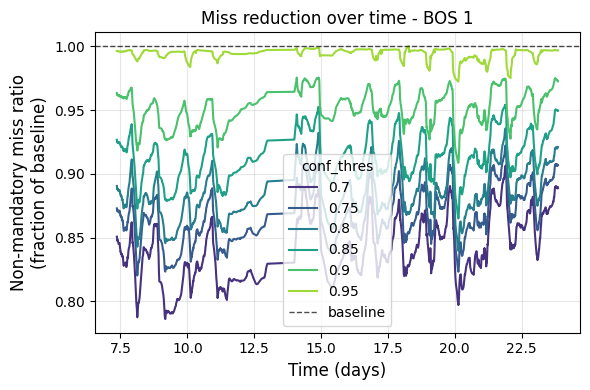

In [12]:
focus_trace = 'cf_c'
start_req = 55_000_000
smooth_win = 44

d = red_plot[(red_plot.trace == focus_trace) & (red_plot['all'] >= start_req)].copy()
d['time_d'] = d['now_ts'] / 86400.0
# Remaining non-mandatory miss ratio as a fraction (0 = all avoidable misses gone, 1 = same as baseline).
d['nonmand_miss_remaining'] = 1.0 - d['nonmand_miss_red_pct'] / 100.0
plot_thresholds = sorted(d.conf_thres.unique())[1:]

fig, ax = plt.subplots(figsize=(6, 4))
for t in plot_thresholds:
    dd = d[d.conf_thres == t].sort_values('now_ts').copy()
    dd['smoothed'] = dd.nonmand_miss_remaining.rolling(smooth_win, min_periods=1, center=True).mean()
    ax.plot(dd.time_d, dd.smoothed, label=f'{t}', color=thres_color[t], linewidth=1.5)
ax.axhline(1.0, color='black', linewidth=1.0, alpha=0.7, linestyle='--', label='baseline')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Non-mandatory miss ratio\n(fraction of baseline)')
ax.tick_params(axis='both')
# ax.legend(title='conf_thres', loc='best', ncol=2, fontsize=16, title_fontsize=17)
ax.legend(title='conf_thres', loc='best')
ax.grid(True, alpha=0.3)
plt.title(f'Miss reduction over time - BOS 1')
plt.tight_layout()

## Remaining non-mandatory miss ratio at conf_thres = 0.8 — per trace
Same metric as above (`1 − reduction` against each trace's own `conf_thres=1.0` baseline), but pinned to `conf_thres=0.8` with one line per trace. Two views: zoomed by time (days 5-20) and by request count (50M-150M).

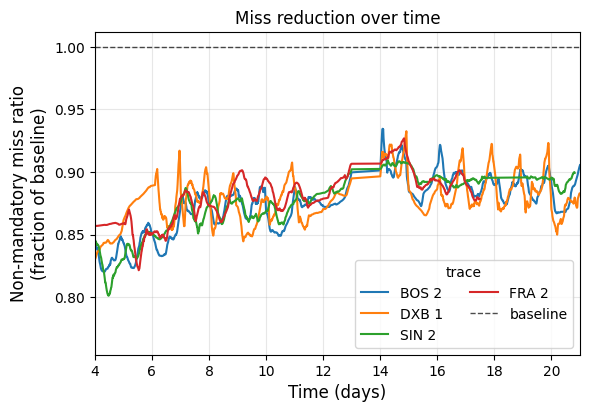

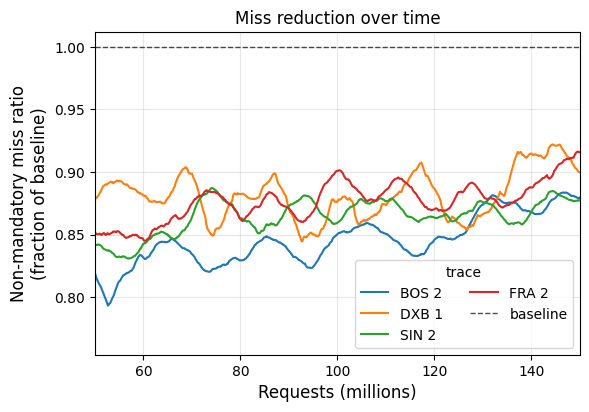

In [29]:
focus_thres = 0.8
smooth_win = 55

d = red_plot[red_plot.conf_thres == focus_thres].copy()
d['time_d'] = d['now_ts'] / 86400.0
d['req_m'] = d['all'] / 1e6
d['nonmand_miss_remaining'] = 1.0 - d['nonmand_miss_red_pct'] / 100.0

plot_traces = sorted(d.trace.unique())
trace_cmap = plt.get_cmap('tab10')
trace_color = {tr: trace_cmap(i) for i, tr in enumerate(plot_traces)}

def _plot(x_col, x_label, xlim, title_suffix):
    fig, ax = plt.subplots(figsize=(6, 4))
    for tr in plot_traces:
        dd = d[d.trace == tr].sort_values('now_ts').copy()
        dd['smoothed'] = dd.nonmand_miss_remaining.rolling(smooth_win, min_periods=1, center=True).mean()
        ax.plot(dd[x_col], dd['smoothed'], label=rename_tbl.get(tr, tr),
                color=trace_color[tr], linewidth=1.5)
    ax.axhline(1.0, color='black', linewidth=1.0, alpha=0.7, linestyle='--', label='baseline')
    ax.set_xlim(*xlim)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Non-mandatory miss ratio\n(fraction of baseline)')
    ax.tick_params(axis='both')
    ax.legend(title='trace', loc='best', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.title(f'Miss reduction over time')
    # return fig

_plot('time_d', 'Time (days)', (4, 21), 'time')
_plot('req_m', 'Requests (millions)', (50, 150), 'requests')